# 32563 Research Project - Ski Jump - Goal 1

# Phase 2

In [1]:
# Goal 1 - Phase 2
# Build a clean labelled jump dataset from all result files (2019-2024)
# Output: processed_jump_dataset.csv

# 1. Import libraries

In [2]:
import os
import glob
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. Locate input files

In [3]:
INPUT_DIR = "/kaggle/input"
WORK_DIR = "/kaggle/working/results_files"

os.makedirs(WORK_DIR, exist_ok=True)

# Find zip files and excel files
zip_files = glob.glob(os.path.join(INPUT_DIR, "**", "*.zip"), recursive=True)
xlsx_files_direct = glob.glob(os.path.join(INPUT_DIR, "**", "*.xlsx"), recursive=True)
xls_files_direct = glob.glob(os.path.join(INPUT_DIR, "**", "*.xls"), recursive=True)

print("ZIP files found:", zip_files[:10])
print("Direct Excel files found:", xlsx_files_direct[:10])
print("Direct XLS files found:", xls_files_direct[:10])

ZIP files found: []
Direct Excel files found: ['/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2020-FIS-RESULTS-DATABASE.xlsx', '/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2021-FIS-RESULTS-DATABASE(incomplete).xlsx', '/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2022-FIS-RESULTS-DATABASE.xlsx', '/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2024-FIS-RESULTS-DATABASE.xlsx', '/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2023-FIS-RESULTS-DATABASE.xlsx', '/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2019-FIS-RESULTS-DATABASE-(remade).xlsx']
Direct XLS files found: []


# 3. Extract zip files if needed

In [4]:
for zf in zip_files:
    print(f"Extracting: {zf}")
    with zipfile.ZipFile(zf, "r") as zip_ref:
        zip_ref.extractall(WORK_DIR)

# After extraction, search again inside working dir
xlsx_files_extracted = glob.glob(os.path.join(WORK_DIR, "**", "*.xlsx"), recursive=True)
xls_files_extracted = glob.glob(os.path.join(WORK_DIR, "**", "*.xls"), recursive=True)

all_excel_files = list(set(xlsx_files_direct + xls_files_direct + xlsx_files_extracted + xls_files_extracted))
all_excel_files = sorted(all_excel_files)

print(f"Total Excel files found: {len(all_excel_files)}")
for f in all_excel_files:
    print(f)


Total Excel files found: 6
/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2019-FIS-RESULTS-DATABASE-(remade).xlsx
/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2020-FIS-RESULTS-DATABASE.xlsx
/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2021-FIS-RESULTS-DATABASE(incomplete).xlsx
/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2022-FIS-RESULTS-DATABASE.xlsx
/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2023-FIS-RESULTS-DATABASE.xlsx
/kaggle/input/datasets/zijianhua/ski-jump-goal-1/2024-FIS-RESULTS-DATABASE.xlsx


# 4. Helper function to read your workbook format

In [5]:
def read_results_file(file_path, sheet_name="RESULTS_DATA"):
    """
    Read one results workbook using row index=2 as the real header.
    """
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=2)
    df.columns = [str(c).strip() for c in df.columns]
    return df


# 5. Test one file first

In [6]:
sample_file = all_excel_files[0]
sample_df = read_results_file(sample_file)

print("Sample file:", sample_file)
print("Shape:", sample_df.shape)
print("Columns:")
print(sample_df.columns.tolist())

sample_df.head()


Sample file: /kaggle/input/datasets/zijianhua/ski-jump-goal-1/2019-FIS-RESULTS-DATABASE-(remade).xlsx
Shape: (2056, 40)
Columns:
['Level', 'Gender', 'Date', 'EventName', 'Season', 'RoundPlace', 'Bib\nNumber', 'FISNum', 'Name', 'Country', 'YOB', 'Round', 'Time', 'Speed', 'Jump1J6', 'Jump1J7', 'Jump1Code', 'Jump1DD', 'Jump1Score', 'Jump2J6', 'Jump2J7', 'Jump2Code', 'Jump2DD', 'Jump2Score', 'JumpScore', 'TurnsBaseJ1', 'TurnsBaseJ2', 'TurnsBaseJ3', 'TurnsBaseJ4', 'TurnsBaseJ5', 'TurnsBaseScore', 'TurnsDeductJ1', 'TurnsDeductJ2', 'TurnsDeductJ3', 'TurnsDeductJ4', 'TurnsDeductJ5', 'TurnsDeductScore', 'TurnsScore', 'Score', 'Advance']


,Level,Gender,Date,EventName,Season,RoundPlace,Bib\nNumber,FISNum,Name,Country,...,TurnsBaseScore,TurnsDeductJ1,TurnsDeductJ2,TurnsDeductJ3,TurnsDeductJ4,TurnsDeductJ5,TurnsDeductScore,TurnsScore,Score,Advance
0,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,1.0,5.0,2484307.0,GALYSHEVA Yulia,KAZ,...,48.5,-0.2,-0.3,-1.6,-0.7,-0.5,-1.5,47.0,76.34,NaN
1,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,2.0,1.0,2531156.0,LAFFONT Perrine,FRA,...,51,-0.7,-0.9,-0.8,-0.5,-0.9,-2.4,48.6,76.04,NaN
2,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,3.0,14.0,2485108.0,HOSHINO Junko,JPN,...,49.3,-1.3,-0.6,-1.1,-0.5,-0.6,-2.3,47.0,75.11,NaN
3,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,4.0,11.0,2532204.0,SUMIYOSHI Kisara,JPN,...,47.4,-0.8,-0.8,-1.2,-0.4,-0.4,-2.0,45.4,73.74,NaN
4,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,5.0,4.0,2485348.0,DUFOUR-LAPOINTE Justine,CAN,...,49.1,-0.3,-0.9,-1.0,-0.8,-0.6,-2.3,46.8,73.47,NaN


# 6. Read and merge all 6 datasets

In [7]:
all_dfs = []

for file_path in all_excel_files:
    try:
        df = read_results_file(file_path, sheet_name="RESULTS_DATA")
        df["SourceFile"] = os.path.basename(file_path)
        all_dfs.append(df)
        print(f"Loaded: {os.path.basename(file_path)} | shape={df.shape}")
    except Exception as e:
        print(f"Failed: {file_path} | error={e}")

raw_data = pd.concat(all_dfs, ignore_index=True)
print("Merged shape:", raw_data.shape)
raw_data.head()


Loaded: 2019-FIS-RESULTS-DATABASE-(remade).xlsx | shape=(2056, 41)
Loaded: 2020-FIS-RESULTS-DATABASE.xlsx | shape=(1680, 41)
Loaded: 2021-FIS-RESULTS-DATABASE(incomplete).xlsx | shape=(315, 41)
Loaded: 2022-FIS-RESULTS-DATABASE.xlsx | shape=(1434, 41)
Loaded: 2023-FIS-RESULTS-DATABASE.xlsx | shape=(2233, 41)
Loaded: 2024-FIS-RESULTS-DATABASE.xlsx | shape=(2009, 57)
Merged shape: (9727, 58)


,Level,Gender,Date,EventName,Season,RoundPlace,Bib\nNumber,FISNum,Name,Country,...,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55
0,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,1.0,5.0,2484307.0,GALYSHEVA Yulia,KAZ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,2.0,1.0,2531156.0,LAFFONT Perrine,FRA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,3.0,14.0,2485108.0,HOSHINO Junko,JPN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,4.0,11.0,2532204.0,SUMIYOSHI Kisara,JPN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,5.0,4.0,2485348.0,DUFOUR-LAPOINTE Justine,CAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 7. Keep useful columns only

In [8]:
columns_needed = [
    "Level",
    "Gender",
    "Date",
    "EventName",
    "Season",
    "RoundPlace",
    "Bib\nNumber",
    "FISNum",
    "Name",
    "Country",
    "YOB",
    "Round",
    "Time",
    "Speed",
    "Jump1Code",
    "Jump1DD",
    "Jump1Score",
    "Jump2Code",
    "Jump2DD",
    "Jump2Score",
    "JumpScore",
    "TurnsScore",
    "Score",
    "Advance",
    "SourceFile"
]

# Keep only columns that actually exist
existing_cols = [c for c in columns_needed if c in raw_data.columns]
data = raw_data[existing_cols].copy()

print("Columns kept:")
print(existing_cols)
print("Shape after column selection:", data.shape)
data.head()


Columns kept:
['Level', 'Gender', 'Date', 'EventName', 'Season', 'RoundPlace', 'Bib\nNumber', 'FISNum', 'Name', 'Country', 'YOB', 'Round', 'Time', 'Speed', 'Jump1Code', 'Jump1DD', 'Jump1Score', 'Jump2Code', 'Jump2DD', 'Jump2Score', 'JumpScore', 'TurnsScore', 'Score', 'Advance', 'SourceFile']
Shape after column selection: (9727, 25)


,Level,Gender,Date,EventName,Season,RoundPlace,Bib\nNumber,FISNum,Name,Country,...,Jump1DD,Jump1Score,Jump2Code,Jump2DD,Jump2Score,JumpScore,TurnsScore,Score,Advance,SourceFile
0,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,1.0,5.0,2484307.0,GALYSHEVA Yulia,KAZ,...,0.93,7.35,fPG,0.93,7.81,15.15,47.0,76.34,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
1,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,2.0,1.0,2531156.0,LAFFONT Perrine,FRA,...,0.83,5.35,7op,1.01,7.37,12.72,48.6,76.04,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
2,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,3.0,14.0,2485108.0,HOSHINO Junko,JPN,...,0.83,5.77,7o,0.98,6.47,12.22,47.0,75.11,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
3,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,4.0,11.0,2532204.0,SUMIYOSHI Kisara,JPN,...,0.75,5.40,bPp,0.83,6.18,11.57,45.4,73.74,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
4,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,5.0,4.0,2485348.0,DUFOUR-LAPOINTE Justine,CAN,...,0.75,5.21,bL,0.82,7.30,12.50,46.8,73.47,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx


# 8. Basic cleaning

In [9]:
# Standardize column names a bit
data = data.rename(columns={
    "Bib\nNumber": "BibNumber"
})

# Convert date
if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

# Convert score columns to numeric
score_cols = ["Jump1Score", "Jump2Score", "JumpScore", "TurnsScore", "Score", "Jump1DD", "Jump2DD", "Time", "Speed"]
for col in score_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9727 entries, 0 to 9726
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Level       9727 non-null   object        
 1   Gender      9727 non-null   object        
 2   Date        9695 non-null   datetime64[ns]
 3   EventName   9695 non-null   object        
 4   Season      9695 non-null   float64       
 5   RoundPlace  9317 non-null   object        
 6   BibNumber   7686 non-null   float64       
 7   FISNum      9695 non-null   object        
 8   Name        9695 non-null   object        
 9   Country     9695 non-null   object        
 10  YOB         9695 non-null   object        
 11  Round       9695 non-null   object        
 12  Time        9695 non-null   float64       
 13  Speed       9695 non-null   float64       
 14  Jump1Code   9695 non-null   object        
 15  Jump1DD     9695 non-null   float64       
 16  Jump1Score  9695 non-nul

# 9. Remove clearly invalid rows

In [10]:
# Remove rows with no athlete name
if "Name" in data.columns:
    data = data[data["Name"].notna()]

# Remove rows with both jump scores missing
data = data[~(data["Jump1Score"].isna() & data["Jump2Score"].isna())]

# Reset index
data = data.reset_index(drop=True)

print("Shape after cleaning:", data.shape)
data.head()


Shape after cleaning: (9695, 25)


,Level,Gender,Date,EventName,Season,RoundPlace,BibNumber,FISNum,Name,Country,...,Jump1DD,Jump1Score,Jump2Code,Jump2DD,Jump2Score,JumpScore,TurnsScore,Score,Advance,SourceFile
0,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,1.0,5.0,2484307.0,GALYSHEVA Yulia,KAZ,...,0.93,7.35,fPG,0.93,7.81,15.15,47.0,76.34,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
1,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,2.0,1.0,2531156.0,LAFFONT Perrine,FRA,...,0.83,5.35,7op,1.01,7.37,12.72,48.6,76.04,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
2,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,3.0,14.0,2485108.0,HOSHINO Junko,JPN,...,0.83,5.77,7o,0.98,6.47,12.22,47.0,75.11,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
3,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,4.0,11.0,2532204.0,SUMIYOSHI Kisara,JPN,...,0.75,5.40,bPp,0.83,6.18,11.57,45.4,73.74,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx
4,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,5.0,4.0,2485348.0,DUFOUR-LAPOINTE Justine,CAN,...,0.75,5.21,bL,0.82,7.30,12.50,46.8,73.47,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx


# 10. Convert Jump1 / Jump2 into long format

In [11]:
jump1_cols = [
    "Level", "Gender", "Date", "EventName", "Season", "RoundPlace", "BibNumber",
    "FISNum", "Name", "Country", "YOB", "Round", "Time", "Speed",
    "Jump1Code", "Jump1DD", "Jump1Score", "JumpScore", "TurnsScore", "Score", "Advance", "SourceFile"
]
jump1_cols = [c for c in jump1_cols if c in data.columns]

jump1 = data[jump1_cols].copy()
jump1 = jump1.rename(columns={
    "Jump1Code": "TrickCode",
    "Jump1DD": "DD",
    "Jump1Score": "JumpScoreSingle"
})
jump1["JumpNumber"] = 1

jump2_cols = [
    "Level", "Gender", "Date", "EventName", "Season", "RoundPlace", "BibNumber",
    "FISNum", "Name", "Country", "YOB", "Round", "Time", "Speed",
    "Jump2Code", "Jump2DD", "Jump2Score", "JumpScore", "TurnsScore", "Score", "Advance", "SourceFile"
]
jump2_cols = [c for c in jump2_cols if c in data.columns]

jump2 = data[jump2_cols].copy()
jump2 = jump2.rename(columns={
    "Jump2Code": "TrickCode",
    "Jump2DD": "DD",
    "Jump2Score": "JumpScoreSingle"
})
jump2["JumpNumber"] = 2

jumps = pd.concat([jump1, jump2], ignore_index=True)
print("Long-format jumps shape:", jumps.shape)
jumps.head()


Long-format jumps shape: (19390, 23)


,Level,Gender,Date,EventName,Season,RoundPlace,BibNumber,FISNum,Name,Country,...,Speed,TrickCode,DD,JumpScoreSingle,JumpScore,TurnsScore,Score,Advance,SourceFile,JumpNumber
0,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,1.0,5.0,2484307.0,GALYSHEVA Yulia,KAZ,...,14.19,bPG,0.93,7.35,15.15,47.0,76.34,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
1,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,2.0,1.0,2531156.0,LAFFONT Perrine,FRA,...,14.72,bPp,0.83,5.35,12.72,48.6,76.04,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
2,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,3.0,14.0,2485108.0,HOSHINO Junko,JPN,...,15.89,bPp,0.83,5.77,12.22,47.0,75.11,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
3,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,4.0,11.0,2532204.0,SUMIYOSHI Kisara,JPN,...,16.77,3,0.75,5.40,11.57,45.4,73.74,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
4,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,5.0,4.0,2485348.0,DUFOUR-LAPOINTE Justine,CAN,...,14.17,3,0.75,5.21,12.50,46.8,73.47,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1


# 11. Remove empty jump rows

In [12]:
jumps = jumps[jumps["JumpScoreSingle"].notna()].copy()
jumps["JumpScoreSingle"] = pd.to_numeric(jumps["JumpScoreSingle"], errors="coerce")
jumps = jumps[jumps["JumpScoreSingle"].notna()].reset_index(drop=True)

print("Shape after removing missing jump rows:", jumps.shape)
jumps.head()


Shape after removing missing jump rows: (19389, 23)


,Level,Gender,Date,EventName,Season,RoundPlace,BibNumber,FISNum,Name,Country,...,Speed,TrickCode,DD,JumpScoreSingle,JumpScore,TurnsScore,Score,Advance,SourceFile,JumpNumber
0,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,1.0,5.0,2484307.0,GALYSHEVA Yulia,KAZ,...,14.19,bPG,0.93,7.35,15.15,47.0,76.34,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
1,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,2.0,1.0,2531156.0,LAFFONT Perrine,FRA,...,14.72,bPp,0.83,5.35,12.72,48.6,76.04,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
2,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,3.0,14.0,2485108.0,HOSHINO Junko,JPN,...,15.89,bPp,0.83,5.77,12.22,47.0,75.11,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
3,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,4.0,11.0,2532204.0,SUMIYOSHI Kisara,JPN,...,16.77,3,0.75,5.40,11.57,45.4,73.74,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1
4,World Cup,L,2018-12-07,World Cup - Ruka (Singles),2019.0,5.0,4.0,2485348.0,DUFOUR-LAPOINTE Justine,CAN,...,14.17,3,0.75,5.21,12.50,46.8,73.47,NaN,2019-FIS-RESULTS-DATABASE-(remade).xlsx,1


# 12.  Check score distribution

count    19389.000000
mean         5.444240
std          2.178543
min          0.000000
25%          4.460000
50%          5.920000
75%          6.950000
max         10.270000
Name: JumpScoreSingle, dtype: float64


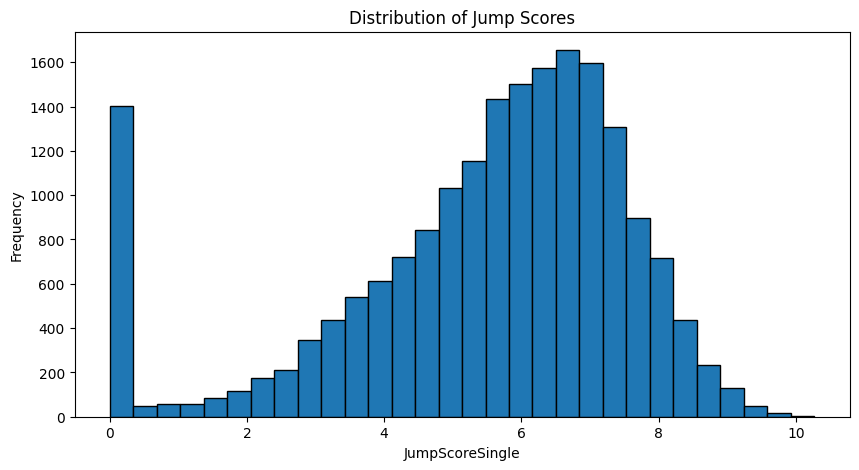

In [13]:
print(jumps["JumpScoreSingle"].describe())

plt.figure(figsize=(10, 5))
plt.hist(jumps["JumpScoreSingle"], bins=30, edgecolor="black")
plt.title("Distribution of Jump Scores")
plt.xlabel("JumpScoreSingle")
plt.ylabel("Frequency")
plt.show()


# 13. Create threshold using 75th percentile

In [14]:
threshold = jumps["JumpScoreSingle"].quantile(0.75)
print("75th percentile threshold =", threshold)

75th percentile threshold = 6.95


# 14. Create Good / Bad label

In [15]:
jumps["Label"] = np.where(jumps["JumpScoreSingle"] >= threshold, "Good", "Bad")

jumps[["Name", "JumpNumber", "JumpScoreSingle", "Label"]].head(10)


,Name,JumpNumber,JumpScoreSingle,Label
0,GALYSHEVA Yulia,1,7.35,Good
1,LAFFONT Perrine,1,5.35,Bad
2,HOSHINO Junko,1,5.77,Bad
3,SUMIYOSHI Kisara,1,5.40,Bad
4,DUFOUR-LAPOINTE Justine,1,5.21,Bad
5,JOHNSON Tess,1,5.40,Bad
6,COX Britteny,1,4.91,Bad
7,JENSON Alex,1,5.72,Bad
8,KAUF Jaelin,1,5.33,Bad
9,KAUF Jaelin,1,5.85,Bad


# 15. Check label balance

Label
Bad     14497
Good     4892
Name: count, dtype: int64


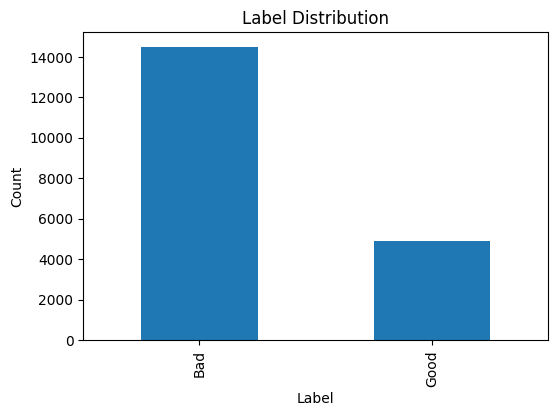

In [16]:
label_counts = jumps["Label"].value_counts()
print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# 16. keep only useful model columns

In [17]:
final_cols = [
    "Name",
    "Country",
    "YOB",
    "Gender",
    "Date",
    "EventName",
    "Season",
    "Round",
    "RoundPlace",
    "BibNumber",
    "FISNum",
    "JumpNumber",
    "TrickCode",
    "DD",
    "Time",
    "Speed",
    "JumpScoreSingle",
    "JumpScore",
    "TurnsScore",
    "Score",
    "Advance",
    "Label",
    "SourceFile"
]

final_cols = [c for c in final_cols if c in jumps.columns]
processed_jumps = jumps[final_cols].copy()

print("Processed dataset shape:", processed_jumps.shape)
processed_jumps.head()


Processed dataset shape: (19389, 23)


,Name,Country,YOB,Gender,Date,EventName,Season,Round,RoundPlace,BibNumber,...,DD,Time,Speed,JumpScoreSingle,JumpScore,TurnsScore,Score,Advance,Label,SourceFile
0,GALYSHEVA Yulia,KAZ,1992.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,Q1:,1.0,5.0,...,0.93,25.68,14.19,7.35,15.15,47.0,76.34,NaN,Good,2019-FIS-RESULTS-DATABASE-(remade).xlsx
1,LAFFONT Perrine,FRA,1998.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,Q1:,2.0,1.0,...,0.83,25.28,14.72,5.35,12.72,48.6,76.04,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
2,HOSHINO Junko,JPN,1989.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,Q1:,3.0,14.0,...,0.83,24.39,15.89,5.77,12.22,47.0,75.11,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
3,SUMIYOSHI Kisara,JPN,2000.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,Q1:,4.0,11.0,...,0.75,23.72,16.77,5.40,11.57,45.4,73.74,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
4,DUFOUR-LAPOINTE Justine,CAN,1994.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,Q1:,5.0,4.0,...,0.75,25.70,14.17,5.21,12.50,46.8,73.47,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx


# 17.  Sort and inspect

In [18]:
sort_cols = [c for c in ["Season", "Date", "EventName", "Round", "Name", "JumpNumber"] if c in processed_jumps.columns]
processed_jumps = processed_jumps.sort_values(sort_cols).reset_index(drop=True)

processed_jumps.head(20)

,Name,Country,YOB,Gender,Date,EventName,Season,Round,RoundPlace,BibNumber,...,DD,Time,Speed,JumpScoreSingle,JumpScore,TurnsScore,Score,Advance,Label,SourceFile
0,ANDRINGA Casey,USA,1995.0,M,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,9.0,12.0,...,0.86,20.73,16.06,7.18,15.44,47.9,79.40,NaN,Good,2019-FIS-RESULTS-DATABASE-(remade).xlsx
1,ANDRINGA Casey,USA,1995.0,M,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,9.0,12.0,...,1.02,20.73,16.06,8.26,15.44,47.9,79.40,NaN,Good,2019-FIS-RESULTS-DATABASE-(remade).xlsx
2,ANTHONY Jakara,AUS,1998.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,6.0,10.0,...,0.75,24.67,15.52,6.11,12.23,48.6,76.35,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
3,ANTHONY Jakara,AUS,1998.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,6.0,10.0,...,0.80,24.67,15.52,6.12,12.23,48.6,76.35,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
4,CAVET Benjamin,FRA,1994.0,M,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,3.0,5.0,...,0.88,21.77,14.45,7.74,16.25,52.8,83.50,NaN,Good,2019-FIS-RESULTS-DATABASE-(remade).xlsx
5,CAVET Benjamin,FRA,1994.0,M,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,3.0,5.0,...,1.02,21.77,14.45,8.52,16.25,52.8,83.50,NaN,Good,2019-FIS-RESULTS-DATABASE-(remade).xlsx
6,COX Britteny,AUS,1994.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,10.0,3.0,...,0.75,24.95,15.15,5.33,10.89,44.5,70.54,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
7,COX Britteny,AUS,1994.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,10.0,3.0,...,0.82,24.95,15.15,5.58,10.89,44.5,70.54,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
8,DUFOUR-LAPOINTE Justine,CAN,1994.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,5.0,4.0,...,0.75,24.63,15.57,5.66,13.04,48.3,76.91,NaN,Bad,2019-FIS-RESULTS-DATABASE-(remade).xlsx
9,DUFOUR-LAPOINTE Justine,CAN,1994.0,L,2018-12-07,World Cup - Ruka (Singles),2019.0,F1:,5.0,4.0,...,0.82,24.63,15.57,7.38,13.04,48.3,76.91,NaN,Good,2019-FIS-RESULTS-DATABASE-(remade).xlsx


# 18. Save output CSV

In [19]:
output_path = "/kaggle/working/processed_jump_dataset.csv"
processed_jumps.to_csv(output_path, index=False)

print("Saved to:", output_path)


Saved to: /kaggle/working/processed_jump_dataset.csv


# 19. Save threshold info

In [20]:
threshold_info = pd.DataFrame({
    "Metric": ["Threshold_Type", "Threshold_Value"],
    "Value": ["75th Percentile", threshold]
})

threshold_info.to_csv("/kaggle/working/label_threshold_info.csv", index=False)
threshold_info

,Metric,Value
0,Threshold_Type,75th Percentile
1,Threshold_Value,6.95


# 20. Quick validation checks

In [21]:
print("Unique athletes:", processed_jumps["Name"].nunique() if "Name" in processed_jumps.columns else "N/A")
print("Unique events:", processed_jumps["EventName"].nunique() if "EventName" in processed_jumps.columns else "N/A")
print("Unique trick codes:", processed_jumps["TrickCode"].nunique() if "TrickCode" in processed_jumps.columns else "N/A")
print("Good/Bad counts:")
print(processed_jumps["Label"].value_counts(dropna=False))

Unique athletes: 791
Unique events: 43
Unique trick codes: 55
Good/Bad counts:
Label
Bad     14497
Good     4892
Name: count, dtype: int64
